# EDA 1 Rerun — Metric Landscape: Cascade & Counter-Cascade - after geo harmonise data repreprocess - 20260625
**Phases A + B of the EDA pipeline**

This notebook profiles all cascade and counter-cascade metric families, discovers the
correlation structure between them, identifies redundant candidates, and constructs the
two surviving derived balance metrics. It produces the **enriched CSV** consumed by all
downstream notebooks.

### Metric families

| Family | Metrics | Interpretation |
|--------|---------|----------------|
| **Cascade** | Net_Cascade, CFI_Churn, CFI_Rate, Pct_Inflow_Wealthier | Inflow from wealthier areas + outflow to poorer areas |
| **Counter-cascade** | Net_Counter, Counter_Churn, Counter_Rate, Pct_Outflow_Wealthier | Outflow to wealthier areas + inflow from poorer areas |
| **Derived (constructed here)** | Cascade_Dominance, Cross_Decile_Share | Balance and intensity of deprivation-crossing flows |

### Data source

`msoa_cascade_features_20260615.csv` — 983 London MSOAs with cascade + counter-cascade
metrics for 2011 and 2021, produced by `data_preprocess_imd_rerank_2015pop_sensitivity_check_20260615.ipynb`.

---

## 1. Setup & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path
import sys, os
from pyprojroot import here

# ── Visualisation theme ──────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight'
})

# ── Paths ────────────────────────────────────────────────────
ROOT = here()

DATA_DIR = ROOT / 'outputs'              # preprocessed CSV 
OUTPUT_DIR = ROOT / 'outputs/rerun_eda_figs_20260625'   # where figures are saved
GEO_PATH   = ROOT / 'data/london_msoa_2011.geojson'  # MSOA boundary file


OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Map utility ──────────────────────────────────────────────
# map_utils.py provides load_london_msoa() and plot_london_choropleth()
sys.path.insert(0, str(ROOT))

from map_utils import load_london_msoa, plot_london_choropleth

In [2]:
# ── Load data ────────────────────────────────────────────────
data_path = DATA_DIR / 'msoa_cascade_features_20260625.csv'
df = pd.read_csv(data_path)

print(f'MSOAs:    {len(df):,}')
print(f'Boroughs: {df["ladnm"].nunique()}')
print(f'Columns:  {df.shape[1]}')
print(f'\nColumn list:\n{list(df.columns)}')

MSOAs:    982
Boroughs: 33
Columns:  45

Column list:
['msoa11cd', 'ladnm', 'Wealth_Decile', 'Wealth_Decile_2019', 'IMD_2010', 'IMD_2019', 'IMD_Rank_2010', 'IMD_Rank_2019', 'IMD_Pctile_2010', 'IMD_Pctile_2019', 'IMD_Pctile_Change', 'IMD_Score_Change', 'Inflow_Wealthier_11', 'Outflow_Poorer_11', 'Total_Inflow_11', 'Total_Outflow_11', 'Total_Migration_11', 'CFI_Churn_11', 'CFI_Rate_11', 'Net_Cascade_11', 'Pct_Inflow_Wealthier_11', 'Inflow_Wealthier_21', 'Outflow_Poorer_21', 'Total_Inflow_21', 'Total_Outflow_21', 'Total_Migration_21', 'CFI_Churn_21', 'CFI_Rate_21', 'Net_Cascade_21', 'Pct_Inflow_Wealthier_21', 'Outflow_Wealthier_11', 'Inflow_Poorer_11', 'Counter_Churn_11', 'Counter_Rate_11', 'Net_Counter_11', 'Pct_Outflow_Wealthier_11', 'Outflow_Wealthier_21', 'Inflow_Poorer_21', 'Counter_Churn_21', 'Counter_Rate_21', 'Net_Counter_21', 'Pct_Outflow_Wealthier_21', 'Net_Cascade_21_alt', 'Inflow_Wealthier_21_alt', 'Outflow_Poorer_21_alt']


In [3]:
# ── Define metric families ────────────────────────────────────
CASCADE_METRICS = ['Net_Cascade', 'CFI_Churn', 'CFI_Rate', 'Pct_Inflow_Wealthier']
COUNTER_METRICS = ['Net_Counter', 'Counter_Churn', 'Counter_Rate', 'Pct_Outflow_Wealthier']

# Four base flows (the raw building blocks)
BASE_FLOWS = ['Inflow_Wealthier', 'Outflow_Poorer', 'Outflow_Wealthier', 'Inflow_Poorer']

# ── Compute deltas (2021 − 2011) ────────────────────────────
for base in CASCADE_METRICS + COUNTER_METRICS:
    df[f'Delta_{base}'] = df[f'{base}_21'] - df[f'{base}_11']

print(f'Deltas computed. Total columns: {df.shape[1]}')

Deltas computed. Total columns: 53


---
## Phase A — What Does the Data Look Like?

---
## 2. Descriptive Statistics: Cascade & Counter-Cascade in Parallel

Side-by-side summary tables for both metric families × both years.
The point is to let the reader immediately see the structural symmetry.

In [4]:
# ── Paired summary table ──────────────────────────────────────
print('=' * 80)
print('CASCADE vs COUNTER-CASCADE — Descriptive Statistics')
print('=' * 80)

pairs = list(zip(CASCADE_METRICS, COUNTER_METRICS))
for casc, counter in pairs:
    c11, c21 = f'{casc}_11', f'{casc}_21'
    cc11, cc21 = f'{counter}_11', f'{counter}_21'
    
    summary = df[[c11, c21, cc11, cc21]].describe().round(2)
    print(f'\n─── {casc}  vs  {counter} ───')
    print(summary.to_string())

CASCADE vs COUNTER-CASCADE — Descriptive Statistics

─── Net_Cascade  vs  Net_Counter ───
       Net_Cascade_11  Net_Cascade_21  Net_Counter_11  Net_Counter_21
count          982.00          982.00          982.00          982.00
mean             0.00            0.00            0.00            0.00
std            397.28          405.02          399.05          427.94
min          -1579.00        -1158.00         -929.00        -1460.00
25%           -273.00         -253.75         -290.00         -293.75
50%            -42.00          -53.00          -63.00          -83.00
75%            283.75          232.00          280.75          270.75
max           1261.00         2446.00         1639.00         2299.00

─── CFI_Churn  vs  Counter_Churn ───
       CFI_Churn_11  CFI_Churn_21  Counter_Churn_11  Counter_Churn_21
count        982.00        982.00            982.00            982.00
mean         630.14        614.19            666.75            686.99
std          280.88        326.4

(Compare the means and spreads across the two families. If cascade and counter-cascade
are mirror processes driven by the same hierarchy position, their summary statistics
should be structurally similar (similar means, similar standard deviations).
The sign convention differs: Net_Cascade = Inflow_Wealthier − Outflow_Poorer,
while Net_Counter = Outflow_Wealthier − Inflow_Poorer.)

#### Observation:



---
## 3. Distribution Comparison: 2011 vs 2021

Overlay histograms for all eight metrics, arranged as a **2 × 4 grid**
(cascade row, counter-cascade row). 

Key question: did both families shift the same way over the decade?

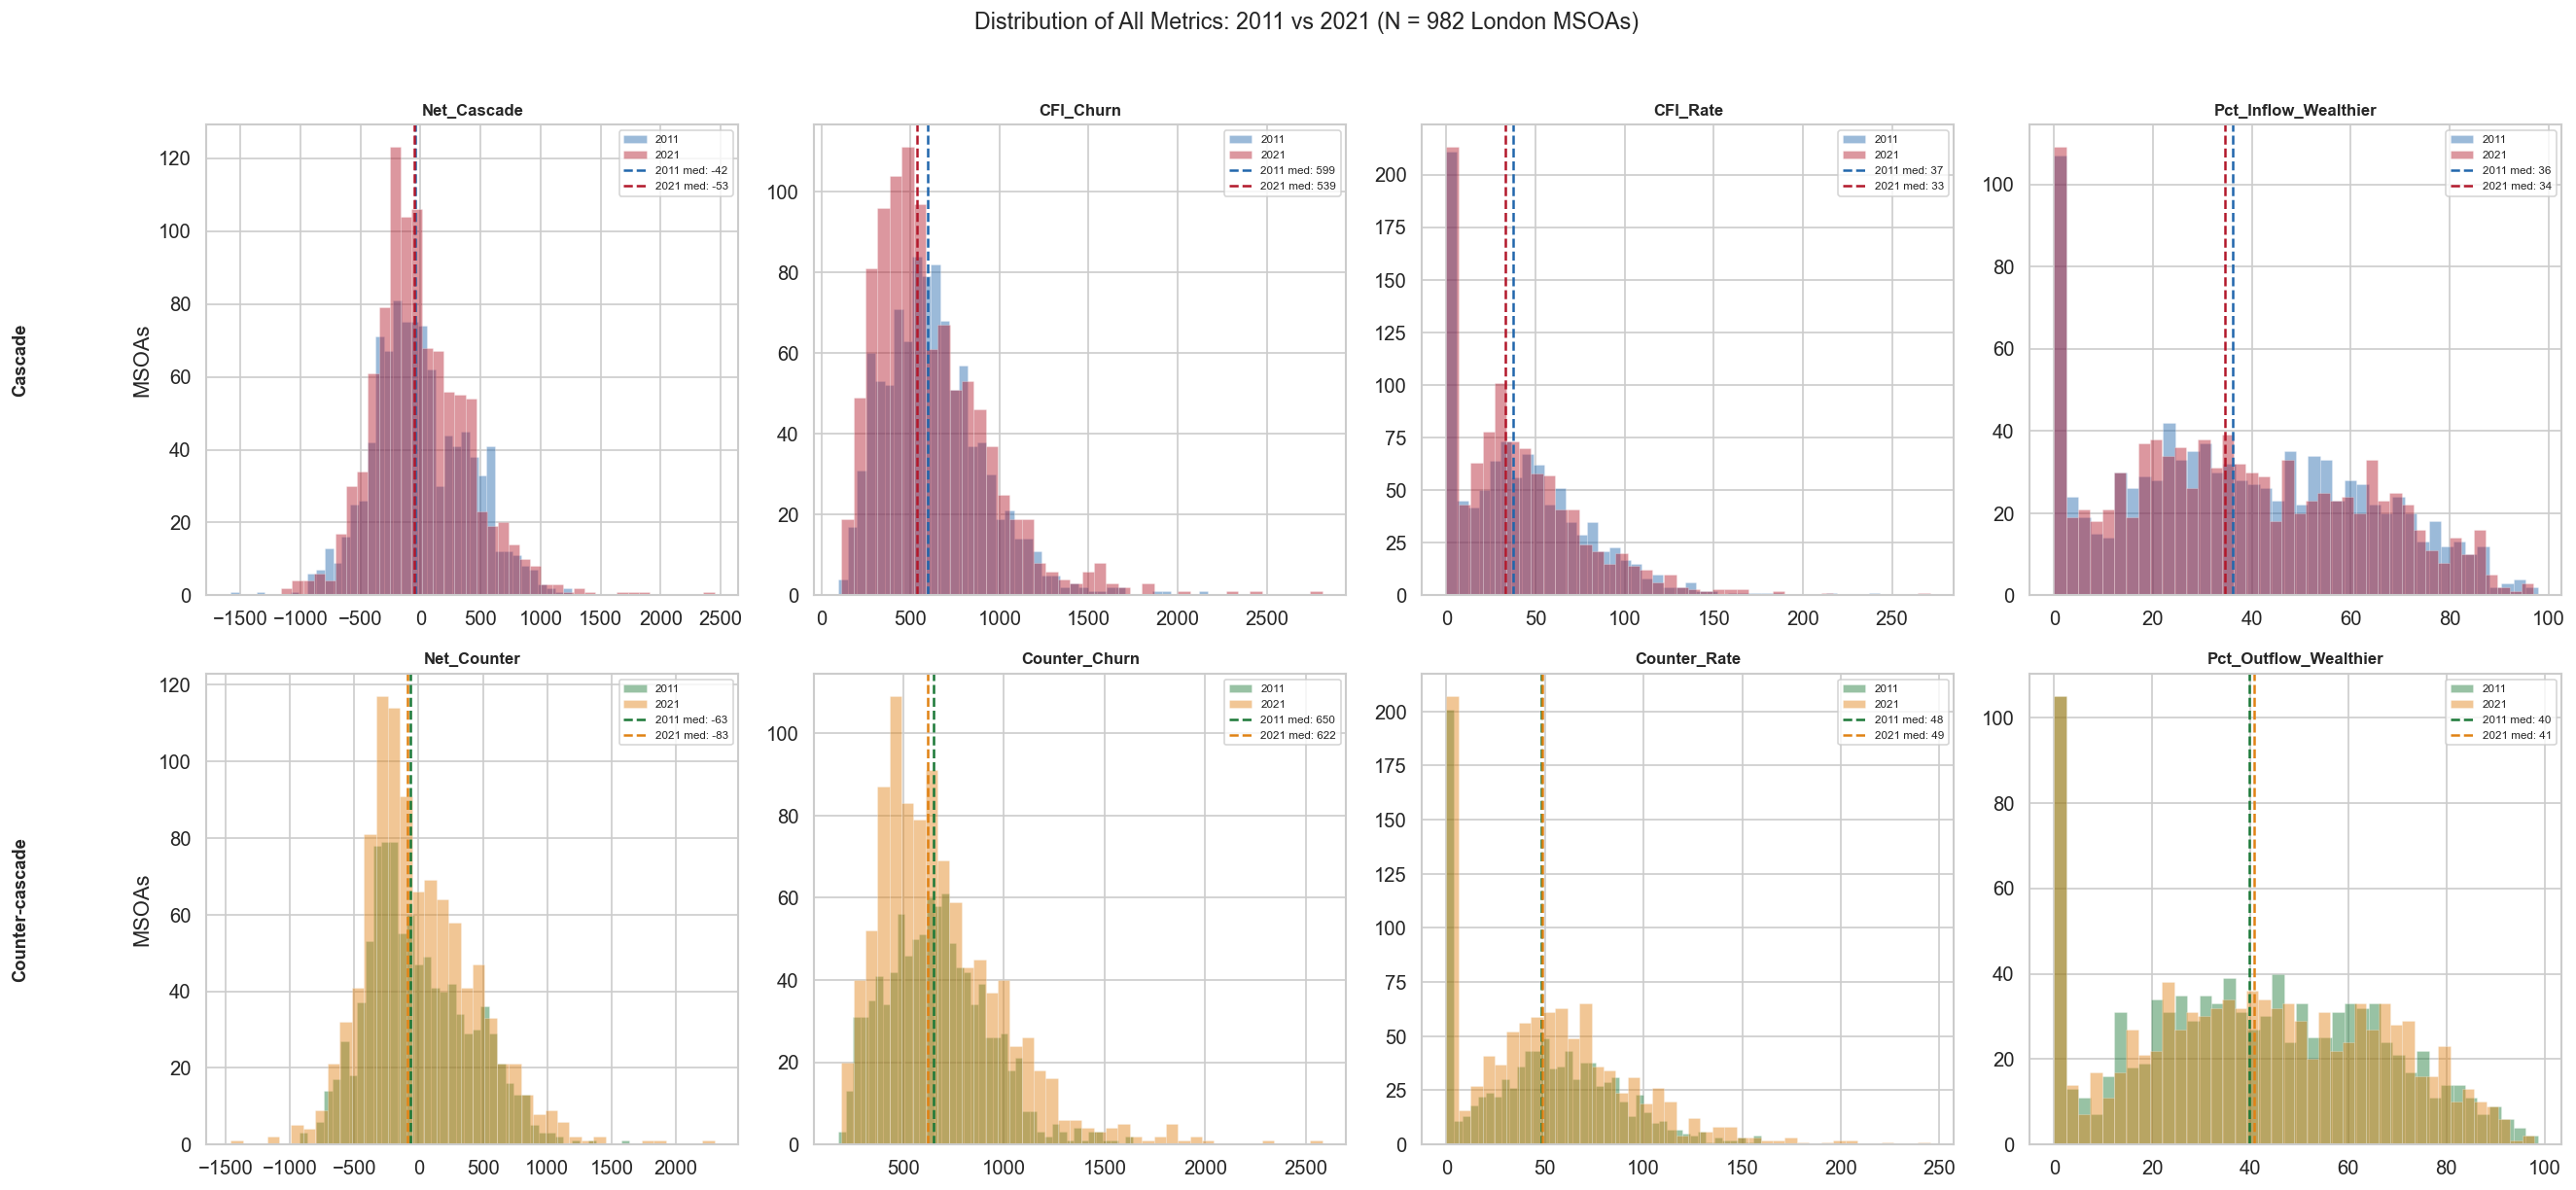

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

row_configs = [
    (CASCADE_METRICS,  'Cascade',         '#2166ac', '#b2182b'),
    (COUNTER_METRICS,  'Counter-cascade', '#1b7837', '#e08214'),
]

for row_idx, (metrics, family_label, c11_color, c21_color) in enumerate(row_configs):
    for col_idx, base in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        c11, c21 = f'{base}_11', f'{base}_21'
        
        ax.hist(df[c11], bins=40, alpha=0.45, color=c11_color, label='2011', edgecolor='white', lw=0.3)
        ax.hist(df[c21], bins=40, alpha=0.45, color=c21_color, label='2021', edgecolor='white', lw=0.3)
        ax.axvline(df[c11].median(), color=c11_color, ls='--', lw=1.5,
                   label=f'2011 med: {df[c11].median():.0f}')
        ax.axvline(df[c21].median(), color=c21_color, ls='--', lw=1.5,
                   label=f'2021 med: {df[c21].median():.0f}')
        
        ax.set_title(f'{base}', fontsize=10, fontweight='bold')
        ax.set_ylabel('MSOAs' if col_idx == 0 else '')
        ax.legend(fontsize=7, loc='upper right')
        
        if row_idx == 0 and col_idx == 0:
            ax.annotate(family_label, xy=(-0.35, 0.5), xycoords='axes fraction',
                        fontsize=11, fontweight='bold', rotation=90, va='center', ha='center')
    
    # Row label for second row
    if row_idx == 1:
        axes[1, 0].annotate(family_label, xy=(-0.35, 0.5), xycoords='axes fraction',
                            fontsize=11, fontweight='bold', rotation=90, va='center', ha='center')

fig.suptitle('Distribution of All Metrics: 2011 vs 2021 (N = 982 London MSOAs)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_01_distributions_cascade_counter.png')
plt.show()

---
## Phase B — How Do the Metrics Relate to Each Other?

This phase discovers the correlation structure empirically, which motivates the construction of new derived metrics and the rejection of redundant candidates.

---
## 4. Full Correlation Matrix

All 8 metrics (both years), deltas, Wealth_Decile, and IMD_Pctile_Change.

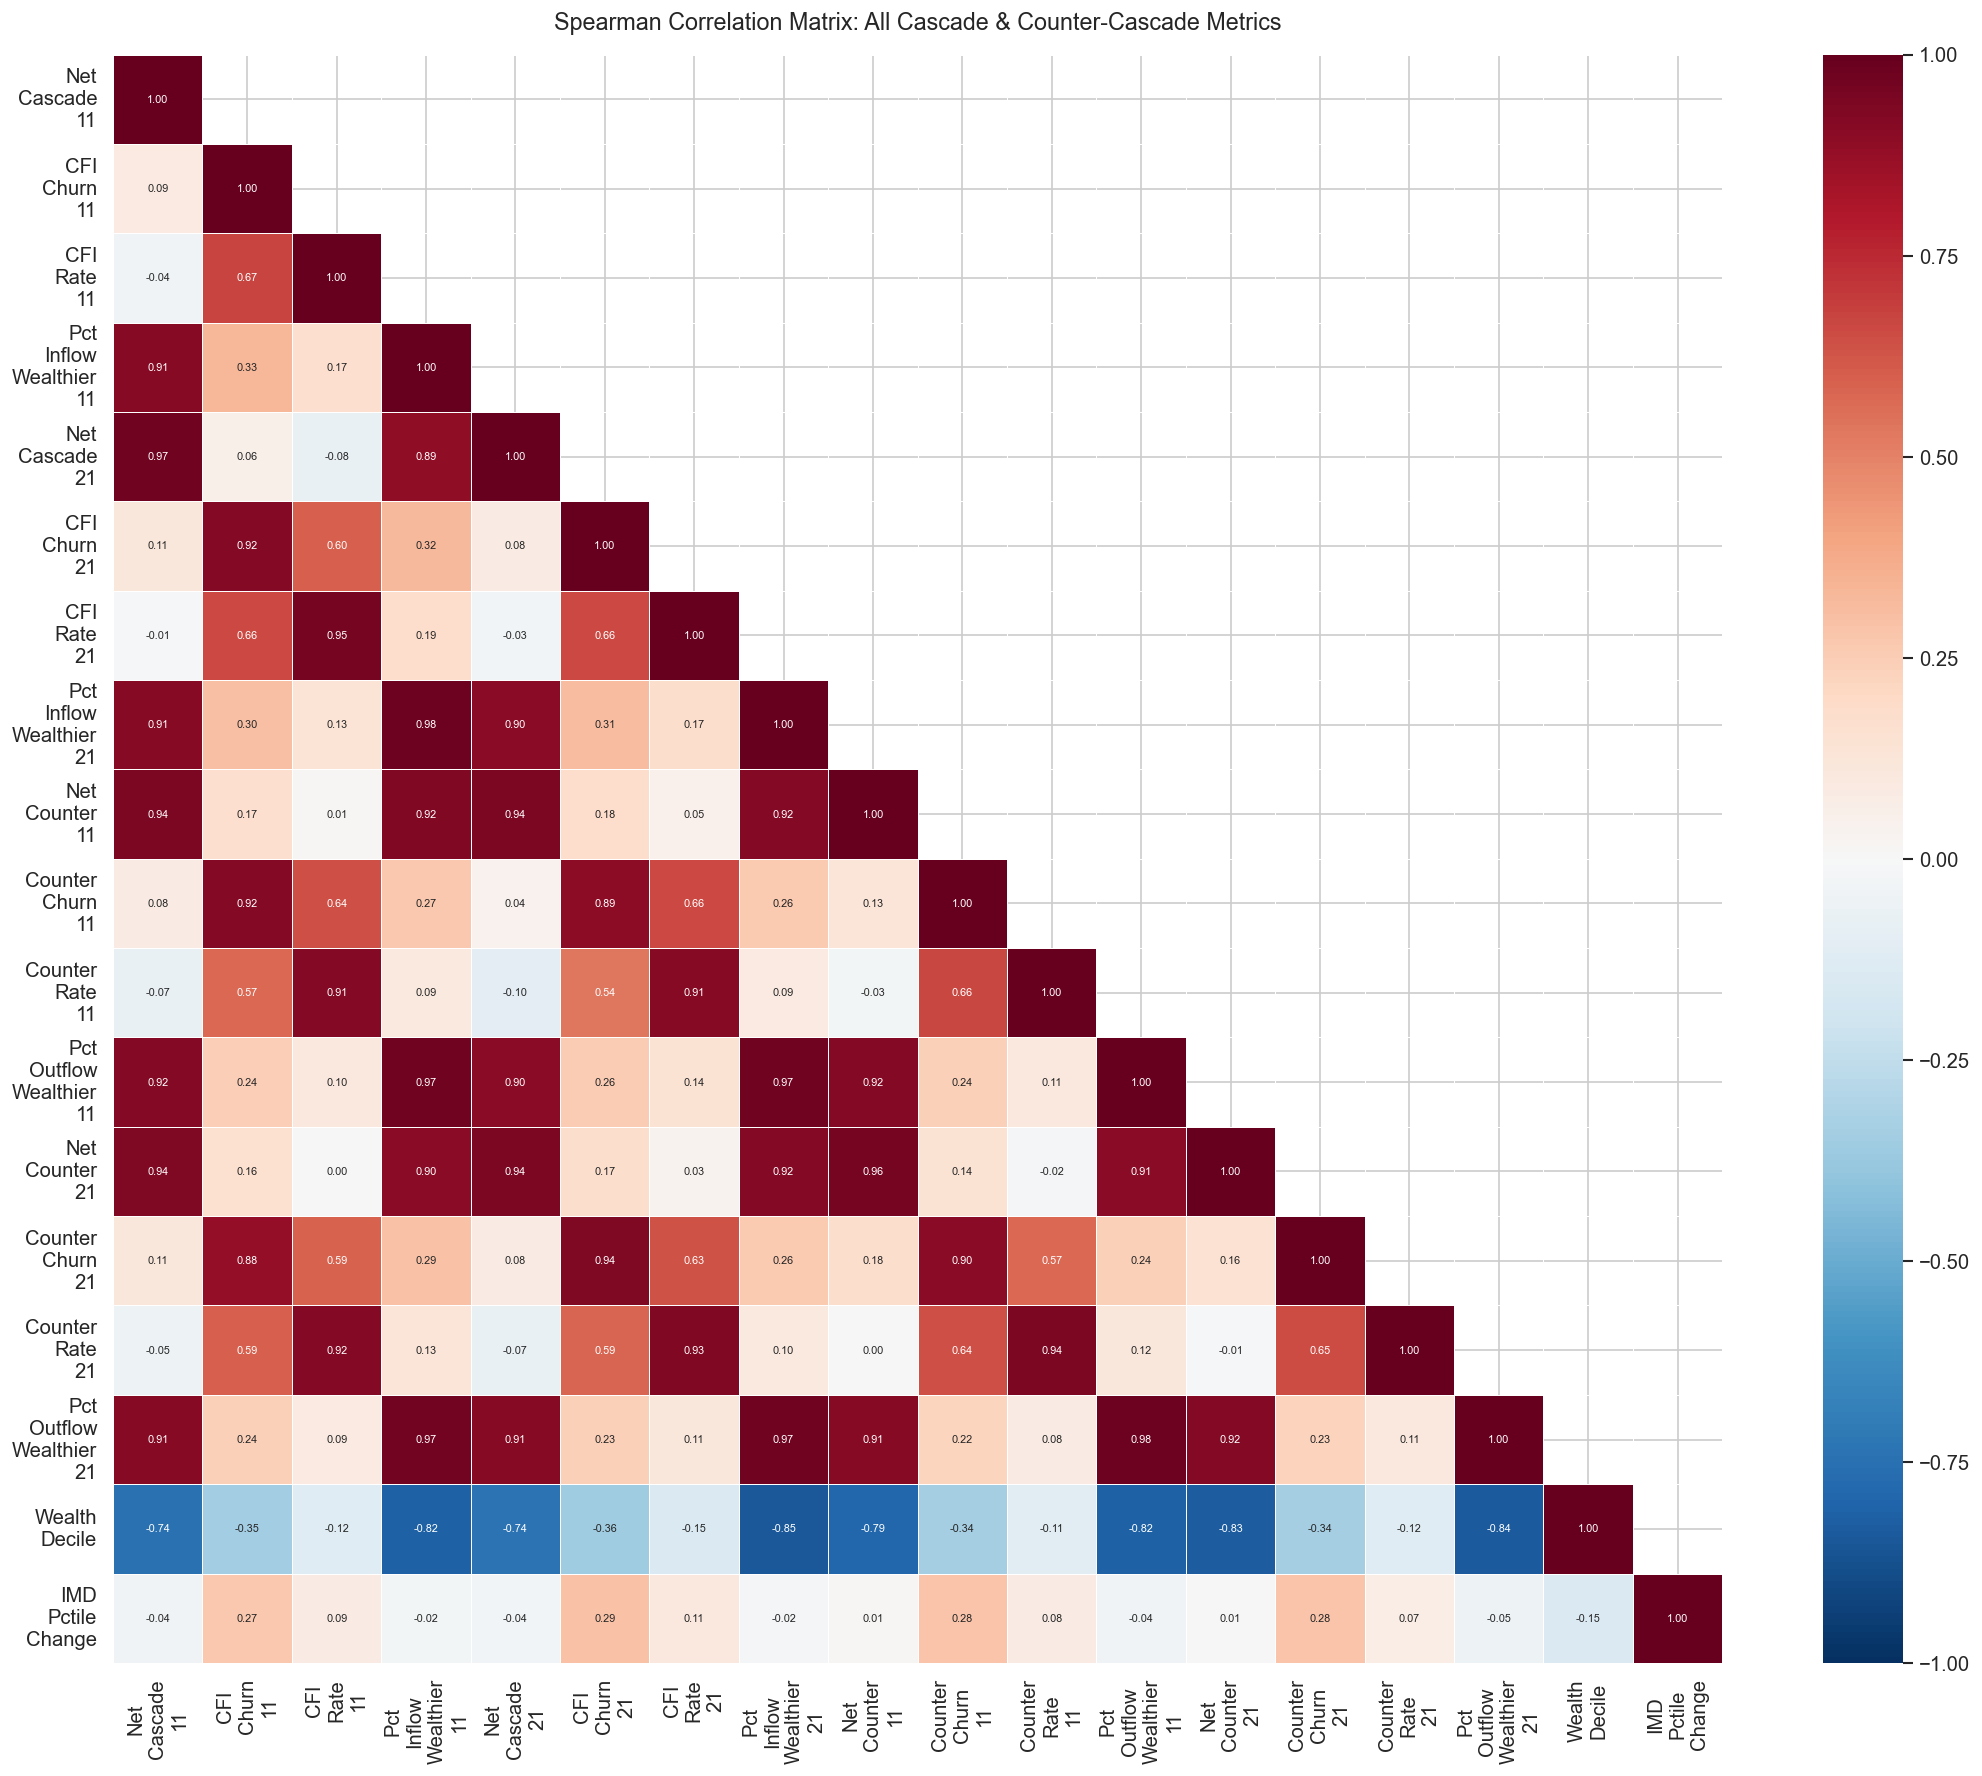

In [6]:
# ── Build the correlation matrix ──────────────────────────────
corr_cols = (
    # Cascade 2011 & 2021
    [f'{m}_11' for m in CASCADE_METRICS] + [f'{m}_21' for m in CASCADE_METRICS]
    # Counter-cascade 2011 & 2021
    + [f'{m}_11' for m in COUNTER_METRICS] + [f'{m}_21' for m in COUNTER_METRICS]
    # Structural
    + ['Wealth_Decile', 'IMD_Pctile_Change']
)

cmat = df[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(cmat, dtype=bool), k=1)

sns.heatmap(cmat, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.3, ax=ax, annot_kws={'size': 6.5},
            xticklabels=[c.replace('_', '\n') for c in corr_cols],
            yticklabels=[c.replace('_', '\n') for c in corr_cols])
ax.set_title('Spearman Correlation Matrix: All Cascade & Counter-Cascade Metrics',
             fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_02_full_correlation_matrix.png')
plt.show()

##### Key patterns to identify
1. **Cascade ↔ counter-cascade mirror**: Net_Cascade vs Net_Counter, CFI_Churn vs Counter_Churn --- Highly correlated.
2. **Churn cluster**: CFI_Churn, Counter_Churn, Total_Migration — All highly correlated.
3. **Hierarchy effect**: metrics correlate most strongly with Wealth_Decile - `Pct_Inflow_Wealthier`, `Net_Counter`, and `Outflow_Wealthier` (> 0.8).
4. **Validation signal**: metrics correlate with IMD_Pctile_Change - None of metrics correlate that much, most are around 0; `CFI_Churn` and `Counter_Churn` are the highest with ~0.25.

---
## 5. Four Base Flows: Pairwise Decomposition

The four base flows (Inflow_Wealthier, Outflow_Poorer, Outflow_Wealthier, Inflow_Poorer) are the building blocks of all cascade and counter-cascade metrics. 

Their pairwise correlation structure reveals *why* the two families **mirror** each other.

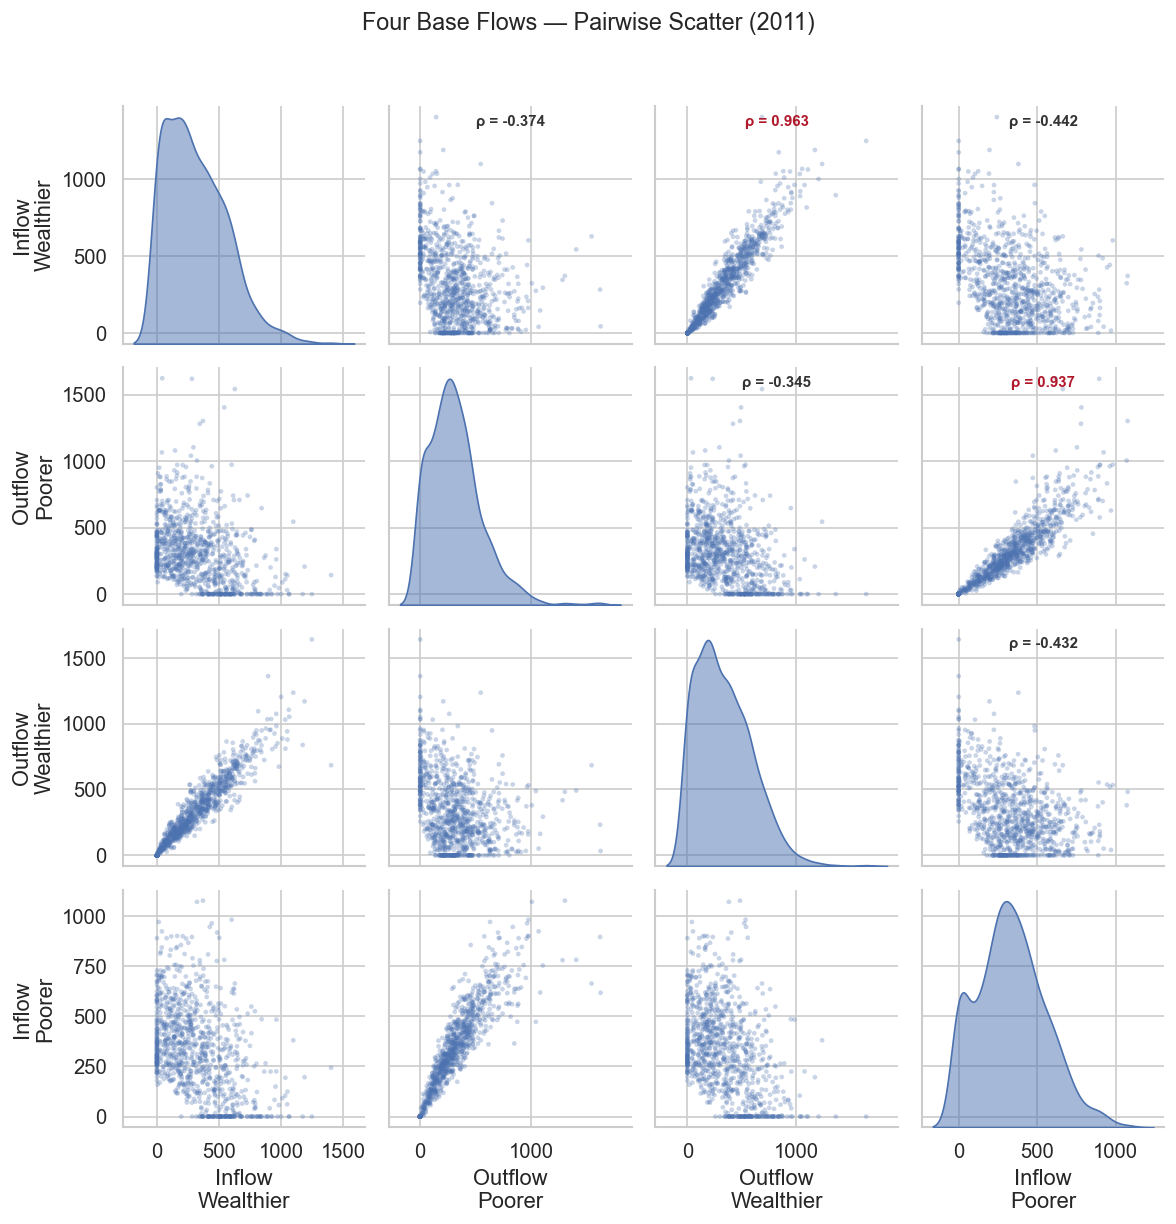

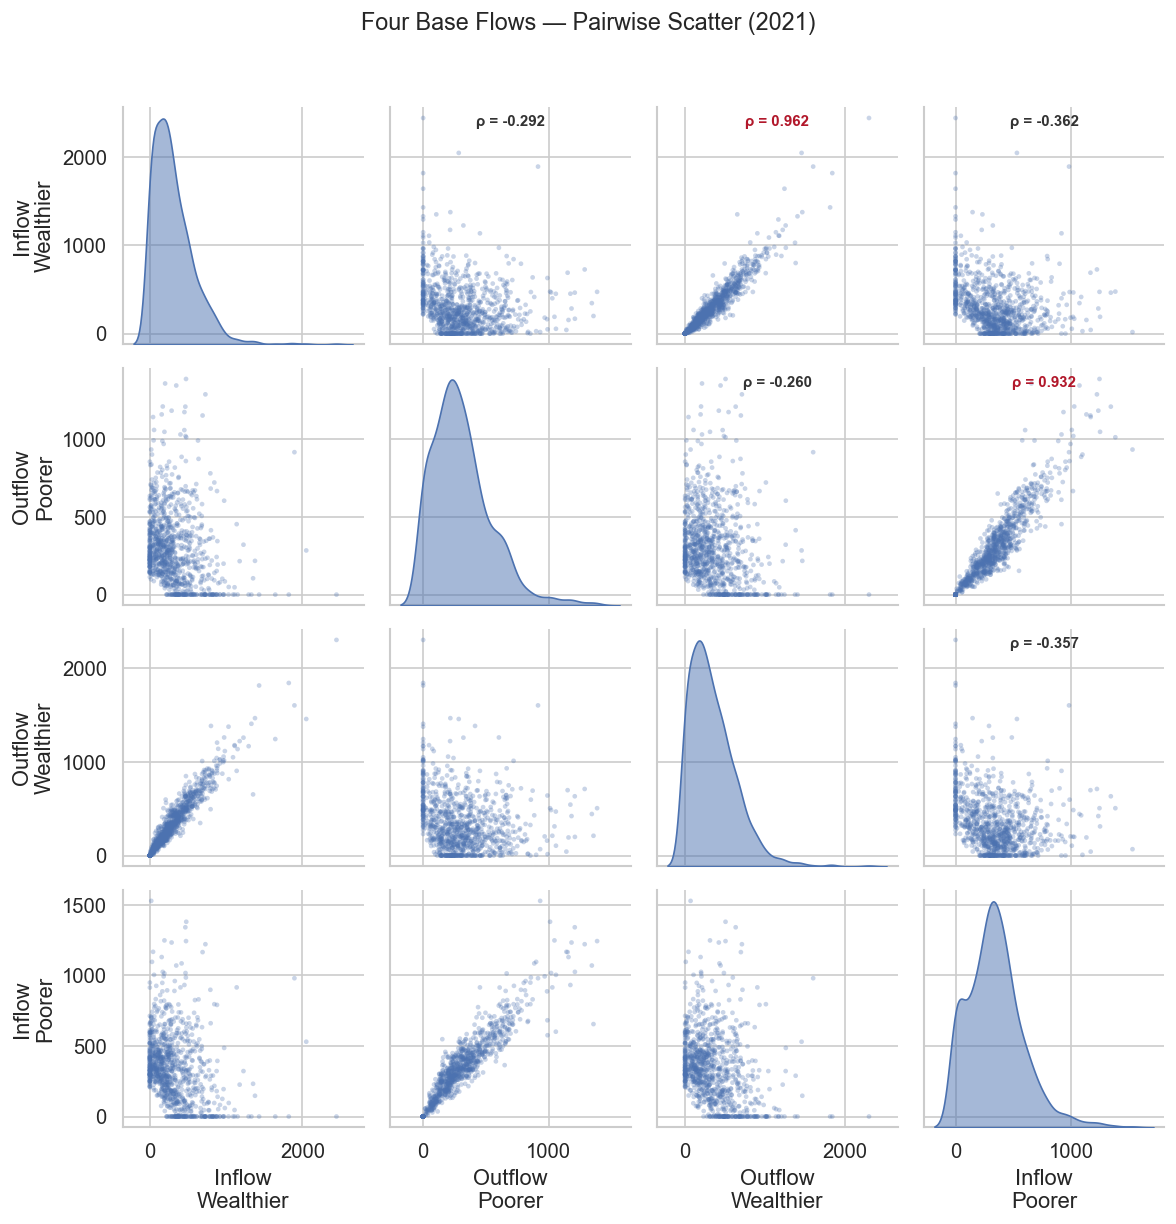

In [7]:
def plot_base_flows(df, year, fig_num):
    """Pairwise scatter matrix of the four base flows for a given census year."""
    suffix = year[-2:]                        # '2011' -> '11', '2021' -> '21'
    flow_cols = [f'{b}_{suffix}' for b in BASE_FLOWS]
    flow_labels = ['Inflow\nWealthier', 'Outflow\nPoorer',
                   'Outflow\nWealthier', 'Inflow\nPoorer']

    g = sns.pairplot(
        df[flow_cols].rename(columns=dict(zip(flow_cols, flow_labels))),
        diag_kind='kde', plot_kws={'s': 8, 'alpha': 0.3, 'edgecolor': 'none'},
        diag_kws={'fill': True, 'alpha': 0.5}
    )
    g.figure.suptitle(f'Four Base Flows — Pairwise Scatter ({year})', y=1.02, fontsize=14)

    for i in range(len(flow_labels)):
        for j in range(len(flow_labels)):
            if i < j:
                rho, _ = stats.spearmanr(df[flow_cols[i]], df[flow_cols[j]])
                g.axes[i, j].annotate(f'ρ = {rho:.3f}', xy=(0.5, 0.92),
                                      xycoords='axes fraction', ha='center',
                                      fontsize=9, fontweight='bold',
                                      color='#b2182b' if abs(rho) > 0.7 else '#333333')

    plt.tight_layout()
    g.savefig(OUTPUT_DIR / f'fig_{fig_num}_four_base_flows_pairplot_{suffix}.png')
    plt.show()
    return g

plot_base_flows(df, '2011', '03a')
plot_base_flows(df, '2021', '03b')

In [8]:
# # ── 2021 base flows: pairwise scatter matrix ─────────────────
# flow_cols_21 = [f'{b}_21' for b in BASE_FLOWS]
# flow_labels = ['Inflow\nWealthier', 'Outflow\nPoorer', 'Outflow\nWealthier', 'Inflow\nPoorer']

# g = sns.pairplot(
#     df[flow_cols_21].rename(columns=dict(zip(flow_cols_21, flow_labels))),
#     diag_kind='kde', plot_kws={'s': 8, 'alpha': 0.3, 'edgecolor': 'none'},
#     diag_kws={'fill': True, 'alpha': 0.5}
# )
# g.figure.suptitle('Four Base Flows — Pairwise Scatter (2021)', y=1.02, fontsize=14)

# # Annotate with Spearman rho in the upper triangle
# for i in range(len(flow_labels)):
#     for j in range(len(flow_labels)):
#         if i < j:
#             rho, _ = stats.spearmanr(df[flow_cols_21[i]], df[flow_cols_21[j]])
#             g.axes[i, j].annotate(f'ρ = {rho:.3f}', xy=(0.5, 0.92),
#                                   xycoords='axes fraction', ha='center',
#                                   fontsize=9, fontweight='bold',
#                                   color='#b2182b' if abs(rho) > 0.7 else '#333333')

# plt.tight_layout()
# plt.savefig(OUTPUT_DIR / 'fig_03_four_base_flows_pairplot.png')
# plt.show()

In [9]:
# ── Print the key correlations explicitly ─────────────────────
print('Pairwise Spearman correlations — Four base flows (2021)')
print('─' * 65)
for i in range(len(BASE_FLOWS)):
    for j in range(i + 1, len(BASE_FLOWS)):
        c1, c2 = f'{BASE_FLOWS[i]}_21', f'{BASE_FLOWS[j]}_21'
        rho, p = stats.spearmanr(df[c1], df[c2])
        marker = ' ◄◄ HIGH' if abs(rho) > 0.9 else ''
        print(f'  {BASE_FLOWS[i]:22s} vs {BASE_FLOWS[j]:22s}  ρ = {rho:+.3f}{marker}')

print()
print('Key finding:')
print('  Inflow_Wealthier ↔ Outflow_Wealthier: ~0.96  (connected to wealthier areas)')
print('  Outflow_Poorer   ↔ Inflow_Poorer:     ~0.93  (connected to poorer areas)')
print('  Cross-pair correlations:               ~0.25  (near-independent)')

Pairwise Spearman correlations — Four base flows (2021)
─────────────────────────────────────────────────────────────────
  Inflow_Wealthier       vs Outflow_Poorer          ρ = -0.292
  Inflow_Wealthier       vs Outflow_Wealthier       ρ = +0.962 ◄◄ HIGH
  Inflow_Wealthier       vs Inflow_Poorer           ρ = -0.362
  Outflow_Poorer         vs Outflow_Wealthier       ρ = -0.260
  Outflow_Poorer         vs Inflow_Poorer           ρ = +0.932 ◄◄ HIGH
  Outflow_Wealthier      vs Inflow_Poorer           ρ = -0.357

Key finding:
  Inflow_Wealthier ↔ Outflow_Wealthier: ~0.96  (connected to wealthier areas)
  Outflow_Poorer   ↔ Inflow_Poorer:     ~0.93  (connected to poorer areas)
  Cross-pair correlations:               ~0.25  (near-independent)


##### Structural interpretation

The four base flows form **two highly correlated pairs**:
- **Wealthier-connected pair**: Inflow_Wealthier ↔ Outflow_Wealthier (ρ ≈ 0.96)
- **Poorer-connected pair**: Outflow_Poorer ↔ Inflow_Poorer (ρ ≈ 0.93)

This means an MSOA that *receives* from wealthier areas also *sends* to wealthier areas. Such MSOA acts as a **transit node** in the hierarchy. 

This is why cascade and counter-cascade metrics mirror each other - both are driven by where an MSOA sits in the deprivation hierarchy relative to its migration partners.

#### Base Flows (from preprocessing)
 
| Column | Description |
|--------|-------------|
| `Inflow_Wealthier` | Migrants arriving from MSOAs in higher (less deprived) wealth deciles |
| `Outflow_Poorer` | Migrants departing to MSOAs in lower (more deprived) wealth deciles |
| `Outflow_Wealthier` | Migrants departing to MSOAs in higher (less deprived) wealth deciles |
| `Inflow_Poorer` | Migrants arriving from MSOAs in lower (more deprived) wealth deciles |
| `Total_Inflow` | All incoming migrants regardless of origin decile |
| `Total_Outflow` | All departing migrants regardless of destination decile |
| `Total_Migration` | Total_Inflow + Total_Outflow |
 
#### Cascade Metrics (from preprocessing)
 
| Metric | Formula | Interpretation |
|--------|---------|----------------|
| `Net_Cascade` | Inflow_Wealthier − Outflow_Poorer | Directional balance of cascade flows. Positive = net inflow from wealthier areas exceeds net outflow to poorer areas |
| `CFI_Churn` | Inflow_Wealthier + Outflow_Poorer | Total intensity of cascade-relevant flows regardless of direction |
| `CFI_Rate` | (Inflow_Wealthier × Outflow_Poorer) / Total_Migration | Co-occurrence of both cascade components, normalised by total migration volume |
| `Pct_Inflow_Wealthier` | (Inflow_Wealthier / Total_Inflow) × 100 | Share of all incoming migrants arriving from less deprived areas |


#### Counter-Cascade Metrics (from preprocessing)
 
| Metric | Formula | Interpretation |
|--------|---------|----------------|
| `Net_Counter` | Outflow_Wealthier − Inflow_Poorer | Directional balance of counter-cascade flows. Positive = net outflow to wealthier areas exceeds net inflow from poorer areas |
| `Counter_Churn` | Outflow_Wealthier + Inflow_Poorer | Total intensity of counter-cascade-relevant flows regardless of direction |
| `Counter_Rate` | (Outflow_Wealthier × Inflow_Poorer) / Total_Migration | Co-occurrence of both counter-cascade components, normalised |
| `Pct_Outflow_Wealthier` | (Outflow_Wealthier / Total_Outflow) × 100 | Share of all departing migrants leaving to less deprived areas |

---
## 6. Redundancy Assessment & Derived Metric Construction

### 6a. Testing candidate balance metrics

Before constructing any new metrics, we test whether the obvious candidates are genuinely non-redundant with what we already have.

#### Candidate Balance Metrics (tested in §6)
 
| Metric | Formula | Verdict | Reason |
|--------|---------|---------|--------|
| `Total_Pressure` | CFI_Churn + Counter_Churn | **Dropped** | ρ = 0.98 with CFI_Churn — effectively redundant |
| `Net_Balance` | Net_Cascade − Net_Counter | **Dropped** | ρ = 0.47 with Wealth_Decile — partly recodes hierarchy position |
| `Churn_Balance` | CFI_Churn − Counter_Churn | **Dropped** | ρ = 0.92 with Cascade_Dominance — redundant unnormalised version |
| `Cascade_Dominance` | CFI_Churn / (CFI_Churn + Counter_Churn) | **Retained** | max \|ρ\| = 0.42 with any existing metric — captures which direction of deprivation-crossing flow dominates |
| `Cross_Decile_Share` | (CFI_Churn + Counter_Churn) / Total_Migration | **Retained** | max \|ρ\| = 0.22 with any existing metric — captures how much migration crosses decile boundaries |

In [10]:
# ── Construct all candidate balance metrics ───────────────────
# (We test them here; only the survivors get kept)

for yr in ['11', '21']:
    cfi  = f'CFI_Churn_{yr}'
    cc   = f'Counter_Churn_{yr}'
    net_c = f'Net_Cascade_{yr}'
    net_cc = f'Net_Counter_{yr}'
    tmig = f'Total_Migration_{yr}'
    
    denom = df[cfi] + df[cc]
    
    # Candidate 1: Total_Pressure
    # Total_Pressure = CFI_Churn + Counter_Churn
    df[f'Total_Pressure_{yr}'] = denom
    
    # Candidate 2: Cascade_Dominance
    # Cascade_Dominance = CFI_Churn / (CFI_Churn + Counter_Churn)
    df[f'Cascade_Dominance_{yr}'] = np.where(denom > 0, df[cfi] / denom, 0.5)
    
    # Candidate 3: Cross_Decile_Share
    # Cross_Decile_Share = (CFI_Churn + Counter_Churn) / Total_Migration
    df[f'Cross_Decile_Share_{yr}'] = np.where(
        df[tmig] > 0, denom / df[tmig], 0)
    
    # Candidate 4: Net_Balance
    # Net_Balance = Net_Cascade - Net_Counter
    df[f'Net_Balance_{yr}'] = df[net_c] - df[net_cc]
    
    # Candidate 5: Churn_Balance
    # Churn_Balance = CFI_Churn - Counter_Churn
    df[f'Churn_Balance_{yr}'] = df[cfi] - df[cc]

print('Candidate metrics constructed for both years.')

Candidate metrics constructed for both years.


In [11]:
# ── Redundancy test: Spearman correlations with existing metrics ──
candidates = ['Total_Pressure', 'Cascade_Dominance', 'Cross_Decile_Share',
              'Net_Balance', 'Churn_Balance']
reference  = ['CFI_Churn', 'Counter_Churn', 'Net_Cascade', 'Net_Counter',
              'Total_Migration', 'Wealth_Decile', 'IMD_Pctile_Change']

print('Spearman ρ of candidate balance metrics vs existing metrics (2021)')
print('=' * 90)
header = f'{"Candidate":>22s}' + ''.join(f'{r:>14s}' for r in reference)
print(header)
print('─' * 90)

for cand in candidates:
    row = f'{cand:>22s}'
    max_rho = 0
    for ref in reference:
        c_col = f'{cand}_21'
        r_col = f'{ref}_21' if ref not in ['Wealth_Decile', 'IMD_Pctile_Change'] else ref
        rho, _ = stats.spearmanr(df[c_col], df[r_col])
        marker = '*' if abs(rho) > 0.9 else ''
        row += f'{rho:>13.3f}{marker}'
        max_rho = max(max_rho, abs(rho))
    verdict = 'REDUNDANT' if max_rho > 0.9 else 'KEEP' if max_rho < 0.5 else 'MARGINAL'
    row += f'  → {verdict}'
    print(row)

print()
print('* = |ρ| > 0.9 (effectively redundant with that reference metric)')
print('* = |ρ| > 0.9 (effectively redundant with that reference metric)')

# ── Cross-check: pairwise redundancy AMONG candidates ─────────
print()
print('Pairwise ρ among candidates (checking if any candidate duplicates another)')
print('─' * 65)
for i in range(len(candidates)):
    for j in range(i + 1, len(candidates)):
        c1, c2 = f'{candidates[i]}_21', f'{candidates[j]}_21'
        rho, _ = stats.spearmanr(df[c1], df[c2])
        flag = ' ◄◄ REDUNDANT PAIR' if abs(rho) > 0.9 else ''
        print(f'  {candidates[i]:>22s} vs {candidates[j]:<22s}  ρ = {rho:+.3f}{flag}')

Spearman ρ of candidate balance metrics vs existing metrics (2021)
             Candidate     CFI_Churn Counter_Churn   Net_Cascade   Net_CounterTotal_Migration Wealth_DecileIMD_Pctile_Change
──────────────────────────────────────────────────────────────────────────────────────────
        Total_Pressure        0.984*        0.983*        0.083        0.167        0.971*       -0.355        0.291  → REDUNDANT
     Cascade_Dominance        0.493        0.187        0.060        0.137        0.319       -0.205        0.093  → KEEP
    Cross_Decile_Share        0.156        0.142       -0.120       -0.135       -0.057        0.101       -0.189  → KEEP
           Net_Balance       -0.307       -0.284       -0.097       -0.389       -0.328        0.461       -0.143  → KEEP
         Churn_Balance        0.194       -0.124        0.010        0.064        0.021       -0.071        0.019  → KEEP

* = |ρ| > 0.9 (effectively redundant with that reference metric)
* = |ρ| > 0.9 (effectively redund

##### Decision gate

Based on the redundancy tests above:

- **Total_Pressure** ≈ CFI_Churn (|ρ| = 0.98) → **DROP** — adds nothing beyond existing churn metrics
- **Net_Balance** moderately driven by Wealth_Decile (ρ = 0.47) → **DROP** — partly recodes hierarchy position, low validation signal
- **Churn_Balance** ≈ Cascade_Dominance (|ρ| = 0.92) → **DROP** — redundant unnormalised version of Dominance
- **Cascade_Dominance** max |ρ| = 0.42 against existing metrics → **KEEP** — captures which direction of deprivation-crossing flow dominates
- **Cross_Decile_Share** max |ρ| = 0.22 against existing metrics → **KEEP** — captures how much migration crosses decile boundaries

We retain **Cascade_Dominance** and **Cross_Decile_Share** as the two non-redundant derived metrics. 
The remaining three candidates are dropped.

In [12]:
# ── Drop redundant candidates, keep the two survivors ─────────
drop_cols = []
for yr in ['11', '21']:
    for cand in ['Total_Pressure', 'Net_Balance', 'Churn_Balance']:
        drop_cols.append(f'{cand}_{yr}')

df.drop(columns=drop_cols, inplace=True)
print(f'Dropped {len(drop_cols)} redundant columns.')
print(f'Retained derived metrics: Cascade_Dominance_11/21, Cross_Decile_Share_11/21')
print(f'Total columns: {df.shape[1]}')

Dropped 6 redundant columns.
Retained derived metrics: Cascade_Dominance_11/21, Cross_Decile_Share_11/21
Total columns: 57


### 6b. Profile the two surviving metrics

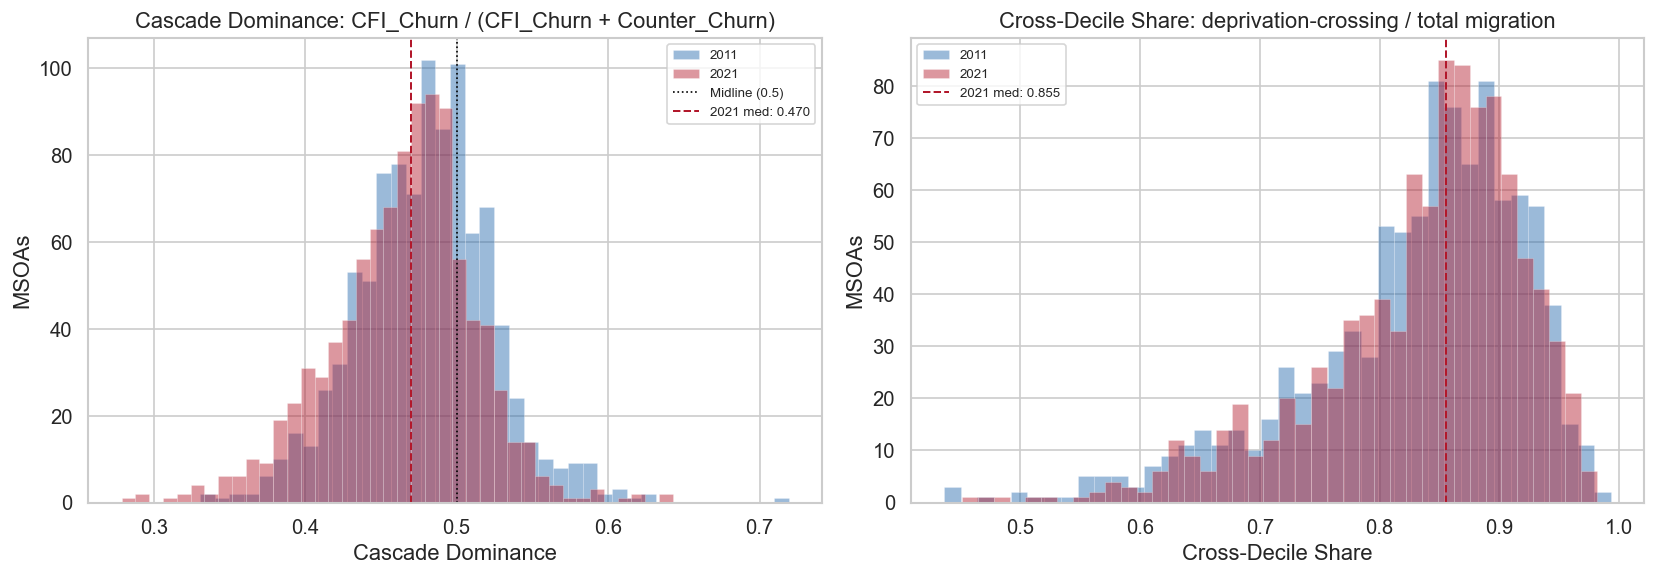


Derived Metric Summary Statistics (2021)
       Cascade_Dominance_21  Cross_Decile_Share_21
count              982.0000               982.0000
mean                 0.4644                 0.8351
std                  0.0474                 0.0863
min                  0.2787                 0.4515
25%                  0.4363                 0.7924
50%                  0.4697                 0.8555
75%                  0.4932                 0.8955
max                  0.6427                 0.9811


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cascade Dominance
ax = axes[0]
ax.hist(df['Cascade_Dominance_11'], bins=40, alpha=0.45, color='#2166ac', label='2011', edgecolor='white', lw=0.3)
ax.hist(df['Cascade_Dominance_21'], bins=40, alpha=0.45, color='#b2182b', label='2021', edgecolor='white', lw=0.3)
ax.axvline(0.5, color='black', ls=':', lw=1, label='Midline (0.5)')
ax.axvline(df['Cascade_Dominance_21'].median(), color='#b2182b', ls='--', lw=1.2,
           label=f'2021 med: {df["Cascade_Dominance_21"].median():.3f}')
ax.set_xlabel('Cascade Dominance')
ax.set_ylabel('MSOAs')
ax.set_title('Cascade Dominance: CFI_Churn / (CFI_Churn + Counter_Churn)')
ax.legend(fontsize=8)

# Cross Decile Share
ax = axes[1]
ax.hist(df['Cross_Decile_Share_11'], bins=40, alpha=0.45, color='#2166ac', label='2011', edgecolor='white', lw=0.3)
ax.hist(df['Cross_Decile_Share_21'], bins=40, alpha=0.45, color='#b2182b', label='2021', edgecolor='white', lw=0.3)
ax.axvline(df['Cross_Decile_Share_21'].median(), color='#b2182b', ls='--', lw=1.2,
           label=f'2021 med: {df["Cross_Decile_Share_21"].median():.3f}')
ax.set_xlabel('Cross-Decile Share')
ax.set_ylabel('MSOAs')
ax.set_title('Cross-Decile Share: deprivation-crossing / total migration')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_04_derived_metrics_distributions.png')
plt.show()

# Print summary stats
print('\nDerived Metric Summary Statistics (2021)')
print(df[['Cascade_Dominance_21', 'Cross_Decile_Share_21']].describe().round(4).to_string())

In [14]:
# check the correlations between two retained metrics for both periods
from scipy import stats

for year in ["11", "21"]:
    rho, p_value = stats.spearmanr(
        df[f"Cascade_Dominance_{year}"],
        df[f"Cross_Decile_Share_{year}"],
        nan_policy="omit",
    )

    print(
        f"20{year}: Spearman rho = {rho:.3f}, "
        f"p = {p_value:.4g}"
    )

2011: Spearman rho = 0.066, p = 0.03929
2021: Spearman rho = 0.116, p = 0.000263


### 6c. Sign concordance flags

Classify each MSOA by whether Net_Cascade and Net_Counter agree in sign.
The ~10% that diverge are the analytically interesting population for Phase D.

#### Classification Flags (constructed in 6c)
 
| Column | Definition | Values |
|--------|------------|--------|
| `Sign_Concordance` | Whether Net_Cascade and Net_Counter share the same sign | `concordant` (~88%), `divergent` (~10%), `zero` (~2%) |
 
#### Temporal Deltas (constructed in this file)
 
All cascade, counter-cascade, and derived metrics have a `Delta_` prefix column computed as `metric_21 − metric_11`, representing the 2011→2021 change.

In [15]:
for yr in ['11', '21']:
    nc = f'Net_Cascade_{yr}'
    ncc = f'Net_Counter_{yr}'
    df[f'Sign_Concordance_{yr}'] = np.where(
        (df[nc] == 0) | (df[ncc] == 0), 'zero',
        np.where(np.sign(df[nc]) == np.sign(df[ncc]), 'concordant', 'divergent')
    )

print('Sign concordance (2021):')
print(df['Sign_Concordance_21'].value_counts().to_string())
print(f'\nDivergent MSOAs: {(df["Sign_Concordance_21"] == "divergent").sum()} / {len(df)}'
      f' ({(df["Sign_Concordance_21"] == "divergent").mean():.1%})')

Sign concordance (2021):
Sign_Concordance_21
concordant    878
divergent     101
zero            3

Divergent MSOAs: 101 / 982 (10.3%)


---
## 7. Diagnostic Map: Baseline Deprivation

A quick spatial orientation — where are the most and least deprived MSOAs?
This map contextualises all subsequent statistical patterns.

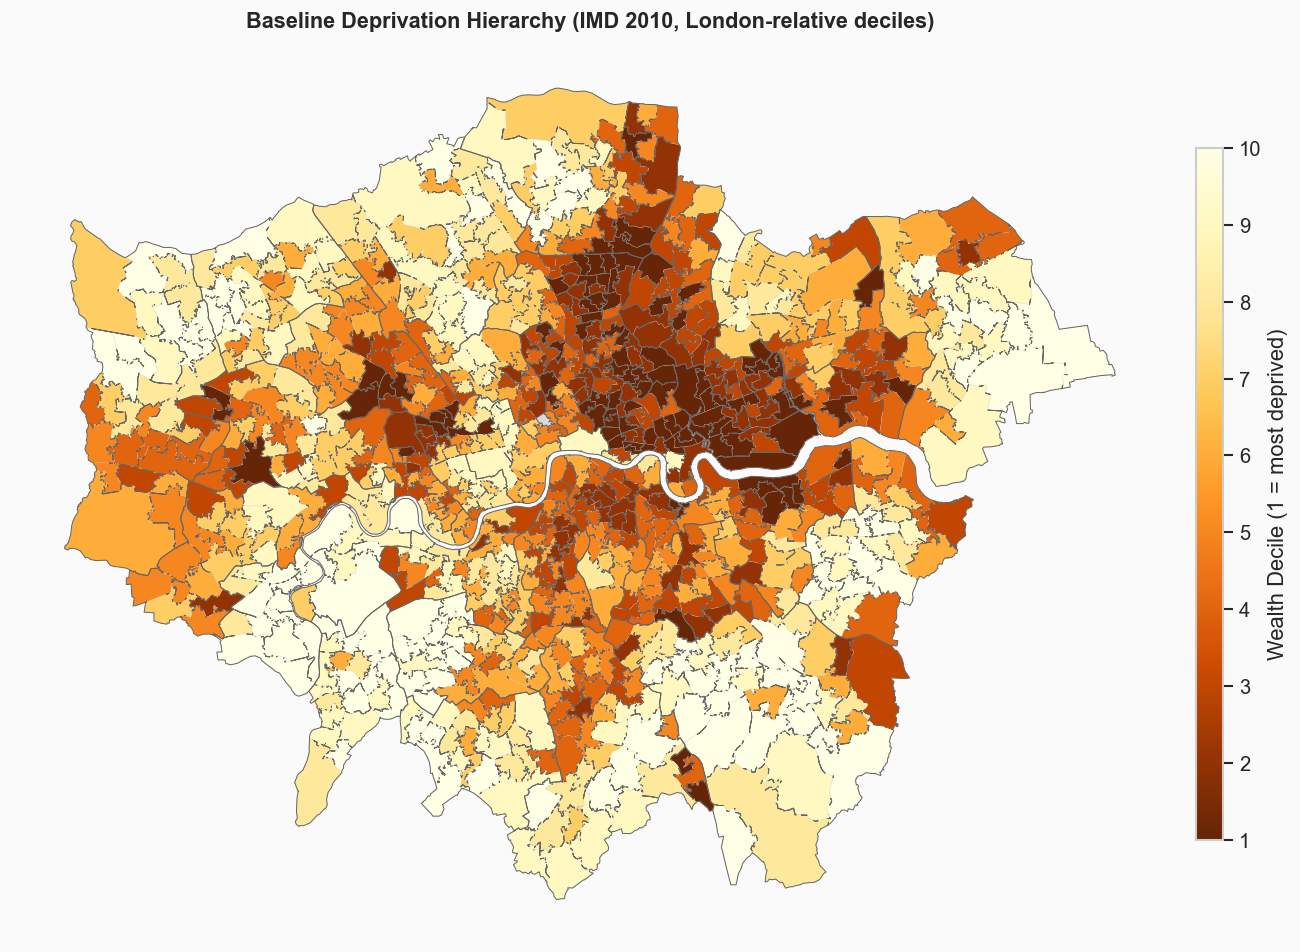

In [16]:
# ── Load geodata and merge ─────────────────────────────────────
gdf = load_london_msoa(GEO_PATH, df)

fig, ax = plot_london_choropleth(
    gdf, column='Wealth_Decile',
    title='Baseline Deprivation Hierarchy (IMD 2010, London-relative deciles)',
    cmap='YlOrBr_r',
    legend_label='Wealth Decile (1 = most deprived)',
    vmin=1, vmax=10
)
plt.savefig(OUTPUT_DIR / 'fig_05_wealth_decile_map.png')
plt.show()

---
## 8. Export Enriched CSV

This is the **single interface** consumed by all downstream EDA notebooks.
It contains the original columns plus: deltas, Cascade_Dominance, Cross_Decile_Share,
and sign concordance flags.

In [17]:
# ── Compute deltas for derived metrics ─────────────────────────
df['Delta_Cascade_Dominance'] = df['Cascade_Dominance_21'] - df['Cascade_Dominance_11']
df['Delta_Cross_Decile_Share'] = df['Cross_Decile_Share_21'] - df['Cross_Decile_Share_11']

# ── Export ─────────────────────────────────────────────────────
export_path = DATA_DIR / 'msoa_cascade_features_enriched_20260625.csv'
df.to_csv(export_path, index=False)

print(f'Enriched CSV exported: {export_path}')
print(f'Shape: {df.shape}')
print(f'\nNew columns added:')
new_cols = [c for c in df.columns if c not in pd.read_csv(data_path).columns]
for c in sorted(new_cols):
    print(f'  {c}')

Enriched CSV exported: /Users/xing/Desktop/CASA/dissertation/outputs/msoa_cascade_features_enriched_20260625.csv
Shape: (982, 61)

New columns added:
  Cascade_Dominance_11
  Cascade_Dominance_21
  Cross_Decile_Share_11
  Cross_Decile_Share_21
  Delta_CFI_Churn
  Delta_CFI_Rate
  Delta_Cascade_Dominance
  Delta_Counter_Churn
  Delta_Counter_Rate
  Delta_Cross_Decile_Share
  Delta_Net_Cascade
  Delta_Net_Counter
  Delta_Pct_Inflow_Wealthier
  Delta_Pct_Outflow_Wealthier
  Sign_Concordance_11
  Sign_Concordance_21


---
## 9. Summary

### Phase A findings
- Cascade and counter-cascade metrics have structurally similar distributions.
- Both families experienced a leftward shift (lower volumes) from 2011 to 2021.

### Phase B findings
- **Cascade ↔ counter-cascade correlation**: Net_Cascade vs Net_Counter ρ ≈ 0.94.
  The two families are largely mirror images, both driven by hierarchy position.
- **Four base flows** form two correlated pairs: wealthier-connected (ρ ≈ 0.96) and
  poorer-connected (ρ ≈ 0.93), with near-zero cross-pair correlation.
- **Redundancy**: Total_Pressure, Net_Balance, and Churn_Balance are redundant with
  existing metrics. Only **Cascade_Dominance** and **Cross_Decile_Share** survive.
- **Sign concordance**: ~90% of MSOAs have concordant signs on Net_Cascade and
  Net_Counter. The ~10% divergent cases are flagged for investigation in File 2.

### Output
`msoa_cascade_features_enriched.csv` — the single interface for all downstream notebooks.

---
*Next: `eda_2_hierarchy_divergence.ipynb` (Phases C + D)*

### Next Step:

-  Need more literatures to know why cascade and counter cascade can mirror each other.
-  Dennett & Stillwell(2008) pointed out the total in/out flows mirror each other, but here we need to show directional in/out flow mirroring.